In [2]:
%pip install -q numpy matplotlib scikit-learn


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
DATASETS = [
	"dataset/dataset_ilann.npz",
	"dataset/dataset_ilann_0306.npz",
	"dataset/dataset_mathis_g.npz",
	"dataset/dataset_mathis_s.npz",
]

import numpy as np

x = np.load(DATASETS[0])["x"]
y = np.load(DATASETS[0])["y"]
for dataset_path in DATASETS[1:]:
	dataset = np.load(dataset_path)
	print(f"number of x points in {dataset_path}: {dataset["x"].shape}")
	print(f"number of y points in {dataset_path}: {dataset["y"].shape}")
	x = np.concatenate([x, dataset["x"]])
	y = np.concatenate([y, dataset["y"]])

y = y.reshape(-1, 1)
print(x.shape)

number of x points in dataset/dataset_ilann_0306.npz: (700, 100, 6)
number of y points in dataset/dataset_ilann_0306.npz: (700,)
number of x points in dataset/dataset_mathis_g.npz: (700, 100, 6)
number of y points in dataset/dataset_mathis_g.npz: (700,)
number of x points in dataset/dataset_mathis_s.npz: (690, 100, 6)
number of y points in dataset/dataset_mathis_s.npz: (690,)
(2790, 100, 6)


['clockwise']
['counter-clock']


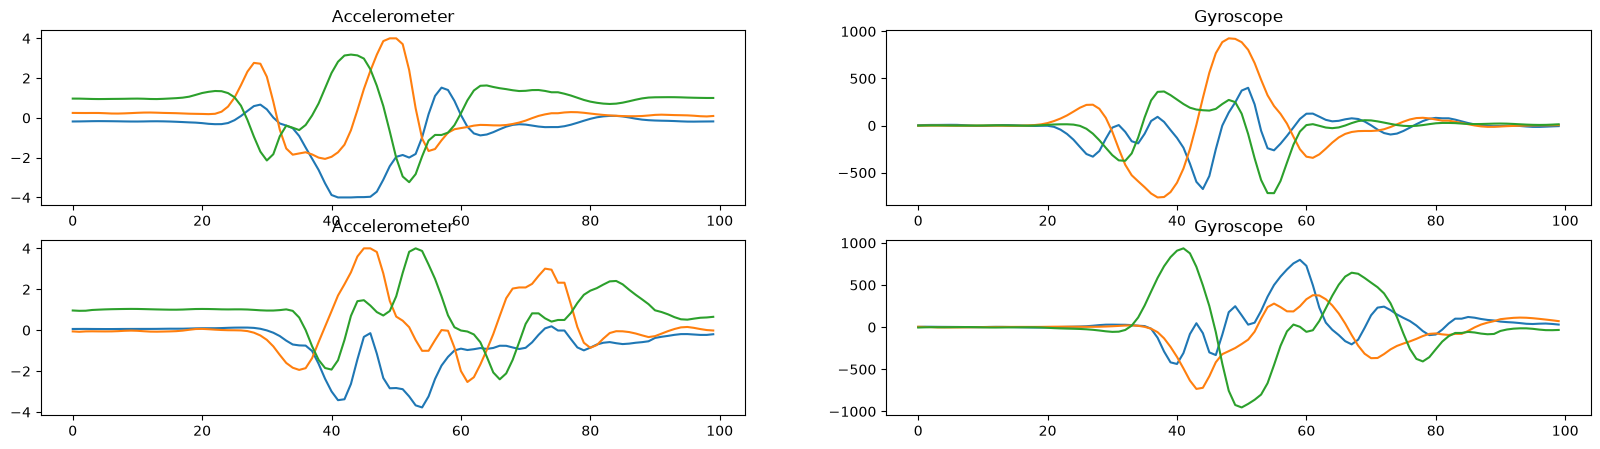

In [4]:
import matplotlib.pyplot as plt

SAMPLE_NUMBER = 490
SAMPLE_NUMBER_TWO = 512

fig, axes = plt.subplots(2, 2, figsize=(20, 5))

axes[0,0].plot(x[SAMPLE_NUMBER, :, 0:3])
axes[0,0].set_title("Accelerometer")
axes[0,1].plot(x[SAMPLE_NUMBER, :, 3:])
axes[0,1].set_title("Gyroscope")

axes[1,0].plot(x[SAMPLE_NUMBER_TWO, :, 0:3])
axes[1,0].set_title("Accelerometer")
axes[1,1].plot(x[SAMPLE_NUMBER_TWO, :, 3:])
axes[1,1].set_title("Gyroscope")

print(y[SAMPLE_NUMBER])
print(y[SAMPLE_NUMBER_TWO])

In [5]:
def calc_features(sample):
	features = np.concatenate([
			np.max(sample, axis=0),
			np.min(sample, axis=0),
			np.average(sample, axis=0),
			# np.argmax(sample, axis=0) - np.argmin(sample, axis=0),
			# np.std(sample, axis=0)
		]).reshape(1, -1)
	return features

x_feat = np.empty(shape=(0, calc_features(x[0]).shape[1]))
print(x_feat)
print(x_feat.shape)

for sample in x:
	new_sample_feat = calc_features(sample)
	x_feat = np.concatenate([x_feat, new_sample_feat])

print(x_feat.shape)

[]
(0, 18)
(2790, 18)


In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_feat, y, test_size=0.2, stratify=y)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(2232, 18)
(2232, 1)
(558, 18)
(558, 1)


In [11]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False)
y_train_enc = enc.fit_transform(y_train)
y_test_enc = enc.transform(y_test)

print(enc.categories_)
print(y_train_enc)


[array(['clockwise', 'counter-clock', 'down', 'left', 'rest', 'right',
       'up'], dtype='<U13')]
[[0. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]]


In [12]:
from sklearn.preprocessing import MinMaxScaler

MIN_RANGE = (-(2**15) + 1) * 0.7
MAX_RANGE = 2**15 * 0.7

enc_features = MinMaxScaler((MIN_RANGE, MAX_RANGE))

x_train_scaled = enc_features.fit_transform(x_train)
print(x_train_scaled.min())
print(x_train_scaled.max())
x_test_scaled = enc_features.transform(x_test)
print(x_test_scaled.min())
print(x_test_scaled.max())

print(enc_features.data_min_)
print(enc_features.data_max_)

-22936.899999999998
22937.600000000006
-29759.71086837857
26417.9289077132
[-8.60351562e-01 -9.67529297e-01 -1.01232910e+00 -2.62451148e+00
 -1.12915030e+01 -4.27246064e-01 -3.99987793e+00 -3.99987793e+00
 -4.00000000e+00 -1.89221179e+03 -1.98889148e+03 -1.59722888e+03
 -1.83697999e+00 -9.86650407e-01 -1.03007197e+00 -1.77443176e+02
 -1.37877792e+02 -1.55195282e+02]
[3.30566406e+00 4.00000000e+00 3.99987793e+00 1.83074939e+03
 1.65588367e+03 1.35900867e+03 9.76928711e-01 9.91210938e-01
 9.94140625e-01 5.12695265e+00 2.07519531e+00 3.29589820e+00
 9.97410893e-01 1.12465703e+00 1.17627931e+00 3.01265717e+02
 1.87058090e+02 2.21770065e+02]


## SCIKIT-LEARN

In [9]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=30, max_depth=10)
model_rf.fit(x_train_scaled, y_train_enc)

model_rf.score(x_test_scaled, y_test_enc)

ValueError: sparse multilabel-indicator for y is not supported.

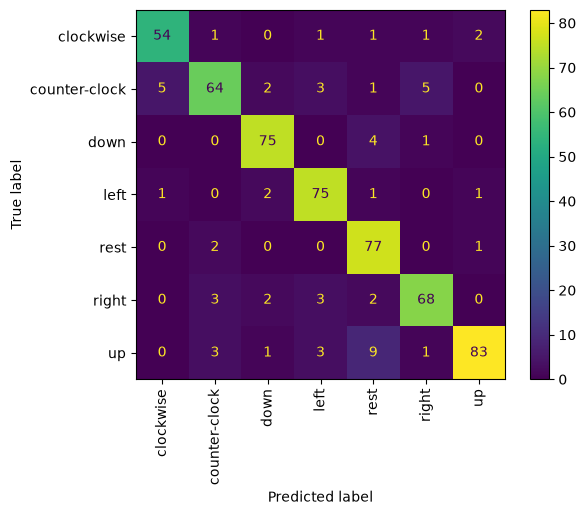

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model_rf, x_test_scaled, y_test_enc, display_labels=enc.classes_, xticks_rotation="vertical")

In [ ]:
from sklearn.metrics import classification_report

y_preds = model_rf.predict(x_test_scaled)

print(classification_report(y_true=y_test_enc, y_pred=y_preds, target_names=enc.classes_))

               precision    recall  f1-score   support

    clockwise       0.90      0.90      0.90        60
counter-clock       0.88      0.80      0.84        80
         down       0.91      0.94      0.93        80
         left       0.88      0.94      0.91        80
         rest       0.81      0.96      0.88        80
        right       0.89      0.87      0.88        78
           up       0.95      0.83      0.89       100

     accuracy                           0.89       558
    macro avg       0.89      0.89      0.89       558
 weighted avg       0.89      0.89      0.89       558



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(x_train_scaled, y_train_enc)
model_knn.score(x_test_scaled, y_test_enc)

0.8709677419354839

In [ ]:
%pip install -q emlearn setuptools


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


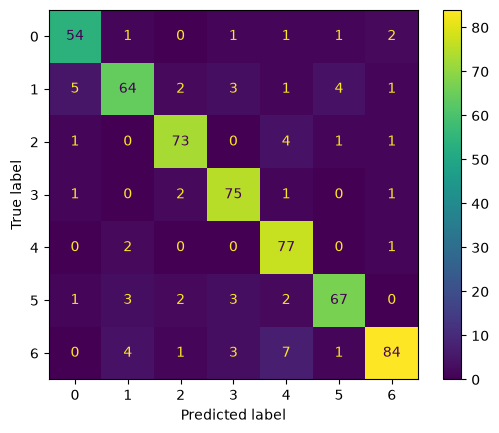

In [ ]:
import emlearn

c_model_rf = emlearn.convert(model_rf, method="inline", dtype="float")
c_model_rf.save("rf_model", "rf_model.h")
y_preds_rf = c_model_rf.predict(x_test_scaled)

ConfusionMatrixDisplay.from_predictions(y_test_enc, y_preds_rf)

In [ ]:
c_model_knn = emlearn.convert(model_knn, method="loadable")
c_model_knn.save("knn_model", "knn_model.h")


'#include <eml_neighbors.h>\nstatic const int16_t knn_model_data[40176] = { -1874, -2439, 22937, -17967, 3372, -15122, -1528, 3067, -13826, 17431, 12296, 17514, 9313, 1151, 13615, -5882, -1297, -3697, -15904, 5273, 13695, -12920, -11065, 568, -2625, 2388, 962, 19223, 16126, 14243, -7594, 4064, 8198, -485, 7794, 5778, -5699, -386, 22937, -15127, -13826, -17879, -20940, 4663, -22936, 15061, 1480, 18782, 2142, 145, 13989, -5356, -2621, -3868, -18694, -11135, 5175, -19285, 11688, 309, -22936, -18334, -1692, 7573, 5329, -6557, -14908, -8388, 11159, -6198, 749, 1005, 114, 18375, 1304, -17906, -20437, -11334, 3632, -3434, 10263, 18247, 19691, 428, 9920, -1354, 14690, -4888, -4983, -6534, -7857, 859, 10435, -19615, -13946, -14727, 5175, 5771, 7890, 17740, 16825, 16590, 4365, 2027, 15744, -9200, -797, -7155, -11266, -7296, 4947, -19632, -17455, -18771, -5474, 4833, 8792, 21405, 14488, 17689, -1815, -6086, 13984, -4286, -8064, -5126, -2451, 8305, 22937, -15639, -12764, -15405, -11193, 8667, -168

In [13]:
# EXTREMELY SLOW

# y_preds_knn = c_model_knn.predict(x_test_scaled)
# ConfusionMatrixDisplay.from_predictions(y_test_enc, y_preds_knn)

## Tensorflow